In [17]:
data_dir = '/home/mjehangir/telomere-sv-analysis/data/'

In [18]:
setwd(data_dir)

In [19]:
# ===============================
# SV Comparison Across Tools
# ===============================

# Load required packages
library(dplyr)
library(ggplot2)
library(GenomicRanges)
library(UpSetR)  # optional, for overlap visualization

In [20]:
# -------------------------------
# 1. Load files
# -------------------------------
savana <- read.delim("savana_all_samples_SVs.bed")
severus <- read.delim("severus_somatic_sv.tsv")
sniffles <- read.delim("sniffles_somatic_merged_svs.tsv")
merged <- read.delim("SVs_merged_all_samples_SVs_v7.txt")

In [21]:
head(all_sv)

,chr,start,end,size,type,sample,tool,count
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>
1,chr1,1101414,1101581,167,BND,2436A,Savana,1
2,chr1,1101581,1101748,167,BND,2436A,Savana,1
3,chr1,1116428,1116460,32,BND,2436A,Savana,1
4,chr1,1116460,1116492,32,BND,2436A,Savana,1
5,chr1,1364479,1364512,33,BND,2436A,Savana,1
6,chr1,1364512,1364545,33,BND,2436A,Savana,1


In [22]:
all_sv <- all_sv %>%
  #mutate(size = abs(as.numeric(end) - as.numeric(start))) %>%  # Recalculate size in base pairs
  filter(size > 50)  # Only keep rows where the size is greater than 0


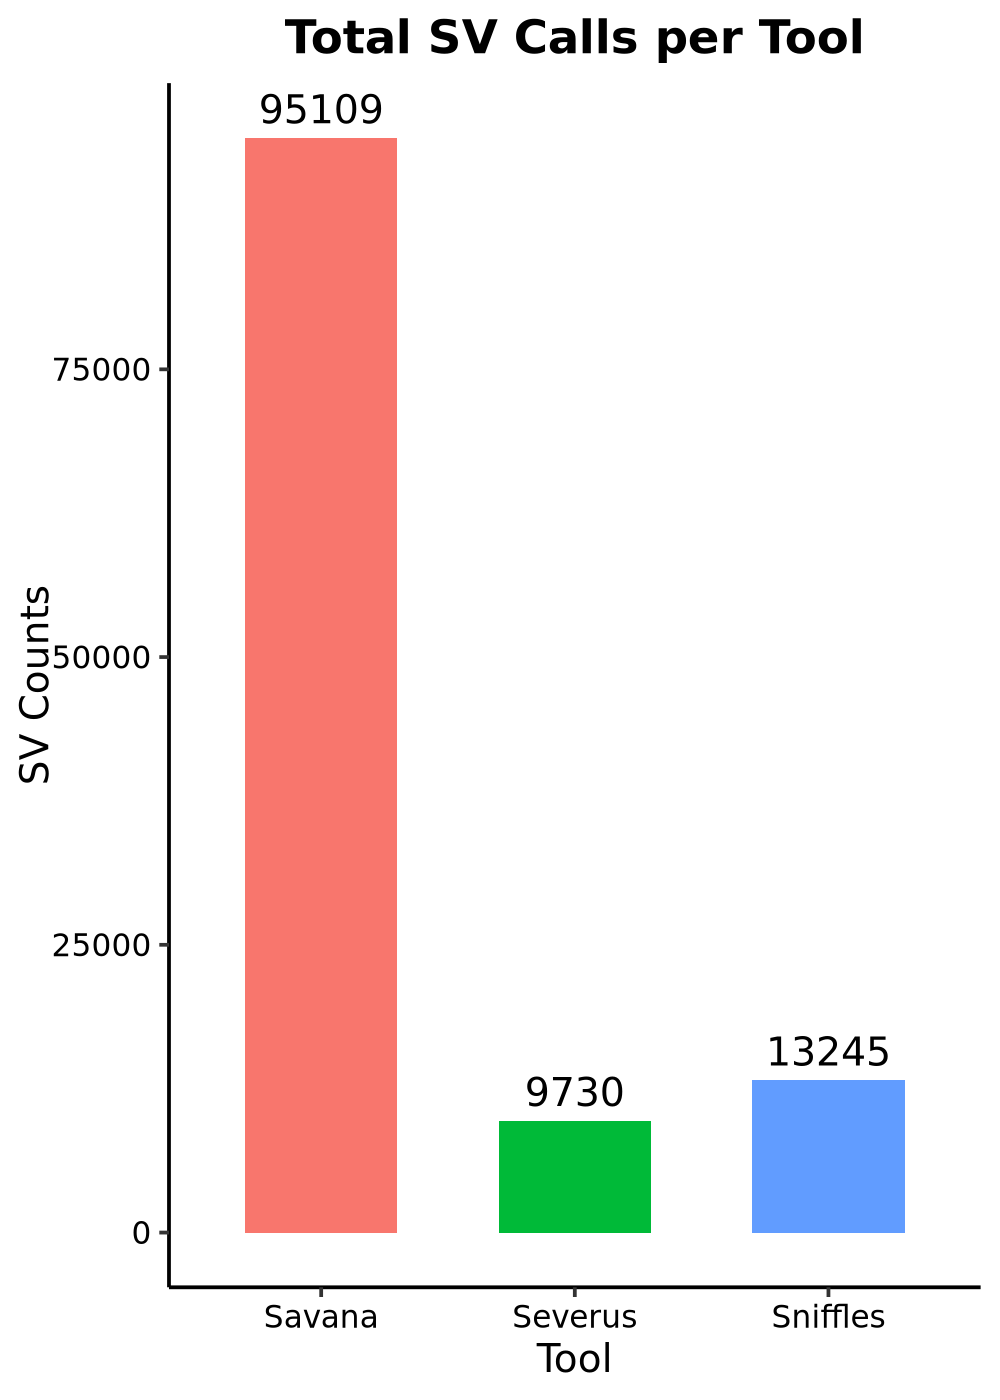

In [23]:
library(dplyr)
library(ggplot2)

# -------------------------------
# Count total SVs per tool
# -------------------------------
sv_total <- all_sv %>%
  group_by(tool) %>%
  summarise(total = n(), .groups = "drop")

# -------------------------------
options(repr.plot.width = 5, repr.plot.height = 7, repr.plot.res = 200)
p_total <- ggplot(sv_total, aes(x = tool, y = total, fill = tool)) +
  geom_bar(stat = "identity", width = 0.6, show.legend = FALSE) +
  geom_text(aes(label = total), vjust = -0.5, size = 5) +  # add counts above bars
  labs(title = "Total SV Calls per Tool",
       x = "Tool",
       y = "SV Counts") +
  theme_bw(base_size = 14) +
  theme(
    panel.border = element_blank(),
    panel.grid = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    plot.title = element_text(hjust = 0.5, face = "bold")
  )

p_total


In [ ]:
# Remove rows with missing start or end
all_sv <- all_sv %>% filter(!is.na(start) & !is.na(end))

# Then create GRanges for each tool
gr_list <- lapply(split(all_sv, all_sv$tool), function(df) {
  GRanges(seqnames = df$chr, ranges = IRanges(start=df$start, end=df$end))
})
head(all_sv)

Warning message in lapply(df[numeric_cols], as.numeric):
“NAs introduced by coercion”


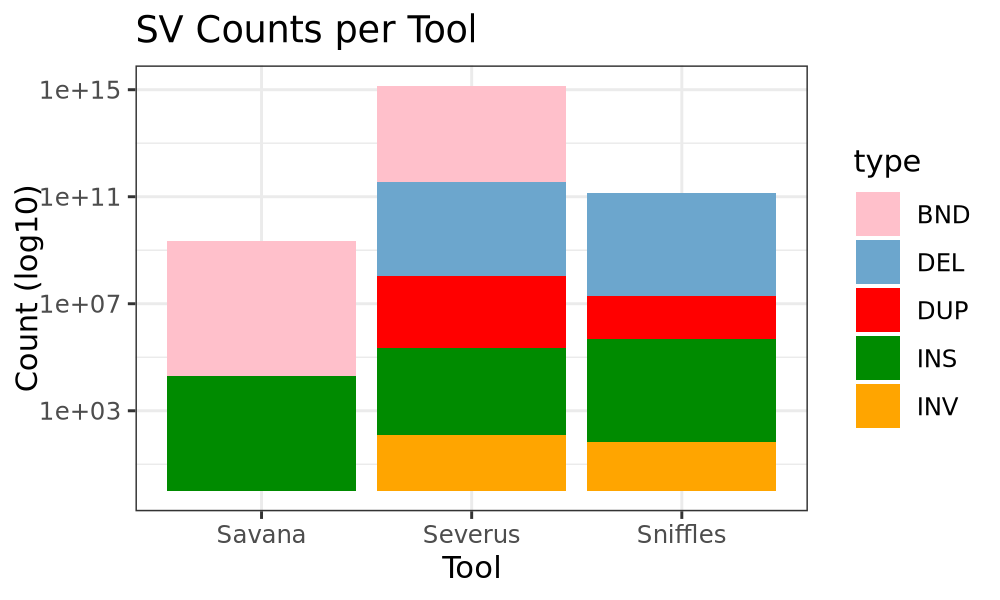

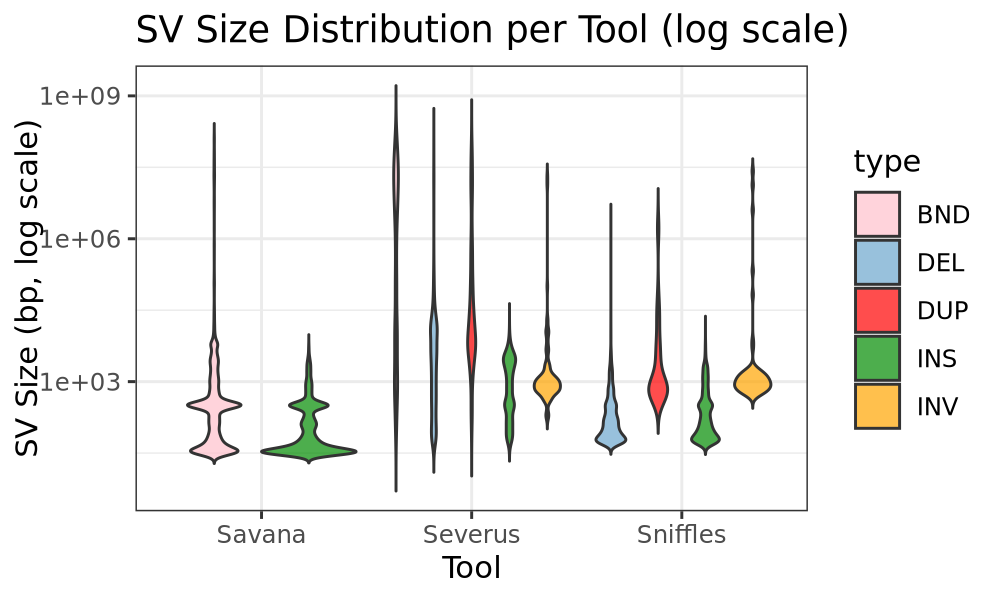

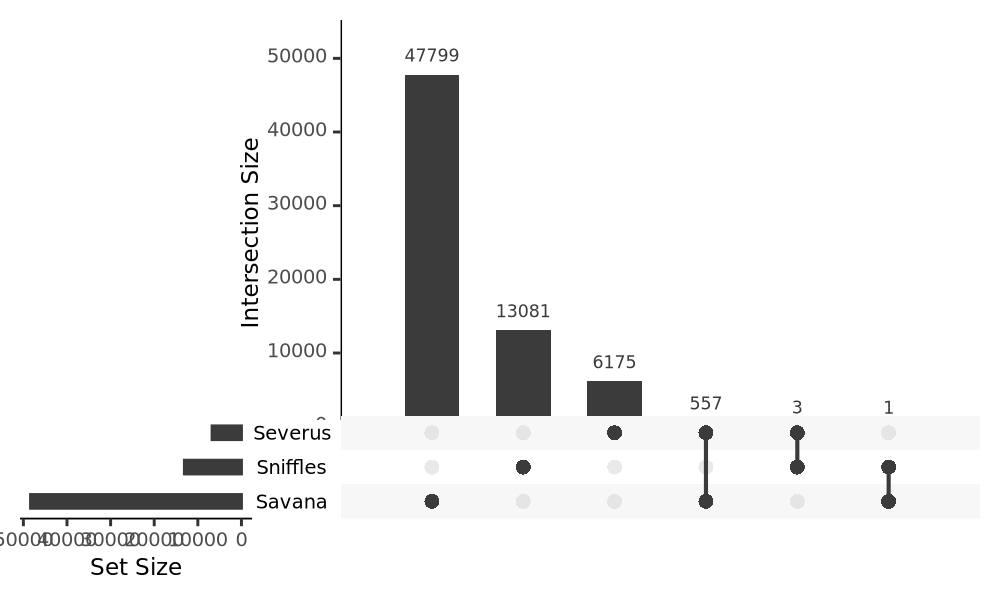

In [11]:
library(dplyr)
library(ggplot2)
library(GenomicRanges)
library(UpSetR)

# -------------------------------
# 1. Standardize columns and add 'tool' identifier
# -------------------------------
cols <- c("chr", "start", "end", "size", "type", "sample")

savana <- savana %>% select(all_of(cols)) %>% mutate(tool="Savana")
severus <- severus %>% select(all_of(cols)) %>% mutate(tool="Severus")
sniffles <- sniffles %>% select(all_of(cols)) %>% mutate(tool="Sniffles")

# -------------------------------
# 2. Ensure correct column types
# -------------------------------
numeric_cols <- c("start", "end", "size")
char_cols <- c("chr", "type", "sample")

datasets <- list(savana, severus, sniffles)
datasets <- lapply(datasets, function(df) {
  df[numeric_cols] <- lapply(df[numeric_cols], as.numeric)
  df[char_cols] <- lapply(df[char_cols], as.character)
  df <- df %>% filter(!is.na(start) & !is.na(end) & size > 0)
  return(df)
})

savana <- datasets[[1]]
severus <- datasets[[2]]
sniffles <- datasets[[3]]

# -------------------------------
# 3. Combine datasets and exclude merged samples
# -------------------------------
all_sv <- bind_rows(savana, severus, sniffles) %>%
  filter(!grepl("merged", sample, ignore.case = TRUE))

# -------------------------------
# 4. Add count per entry for plotting
# -------------------------------
all_sv <- all_sv %>%
  mutate(count = 1)  # Each row = 1 SV
options(repr.plot.width = 5, repr.plot.height = 3, repr.plot.res = 200)

# -------------------------------
# 5. Define SV colors
# -------------------------------
sv_colors <- c("DEL"="skyblue3", "DUP"="red", "INV"="orange", "INS"="green4", "BND"="pink")

# -------------------------------
# 6. Panel A: SV counts per tool (log scale)
# -------------------------------
p1 <- all_sv %>%
  group_by(tool, type) %>%
  summarise(count = sum(count), .groups="drop") %>%
  ggplot(aes(x = tool, y = count, fill = type)) +
  geom_bar(stat="identity", position="stack") +
  scale_y_log10() +
  scale_fill_manual(values=sv_colors) +
  labs(title = "SV Counts per Tool", x = "Tool", y = "Count (log10)") +
  theme_bw() +
  theme(axis.text.x = element_text(angle=0, hjust=0.5))

# -------------------------------
# 7. Panel B: SV size distribution per tool
# -------------------------------
p2 <- all_sv %>%
  ggplot(aes(x=tool, y=size, fill=type)) +
  geom_violin(trim=FALSE, alpha=0.7) +
  scale_y_log10() +
  scale_fill_manual(values=sv_colors) +
  labs(title="SV Size Distribution per Tool (log scale)", 
       x="Tool", y="SV Size (bp, log scale)") +
  theme_bw() +
  theme(axis.text.x = element_text(angle=0, hjust=0.5))


# -------------------------------
# 9. Display plots
# -------------------------------
print(p1)
print(p2)
# -------------------------------
# 8. UpSet plot: Overlaps by tool
# -------------------------------
gr_list <- lapply(split(all_sv, all_sv$tool), function(df) {
  GRanges(seqnames = df$chr, ranges = IRanges(start=df$start, end=df$end))
})

presence_df <- lapply(gr_list, function(gr) {
  paste0(seqnames(gr), ":", start(gr), "-", end(gr))
})

all_ids <- unique(unlist(presence_df))
presence_mat <- sapply(presence_df, function(ids) as.integer(all_ids %in% ids))
rownames(presence_mat) <- all_ids

upset(as.data.frame(presence_mat), order.by="freq")

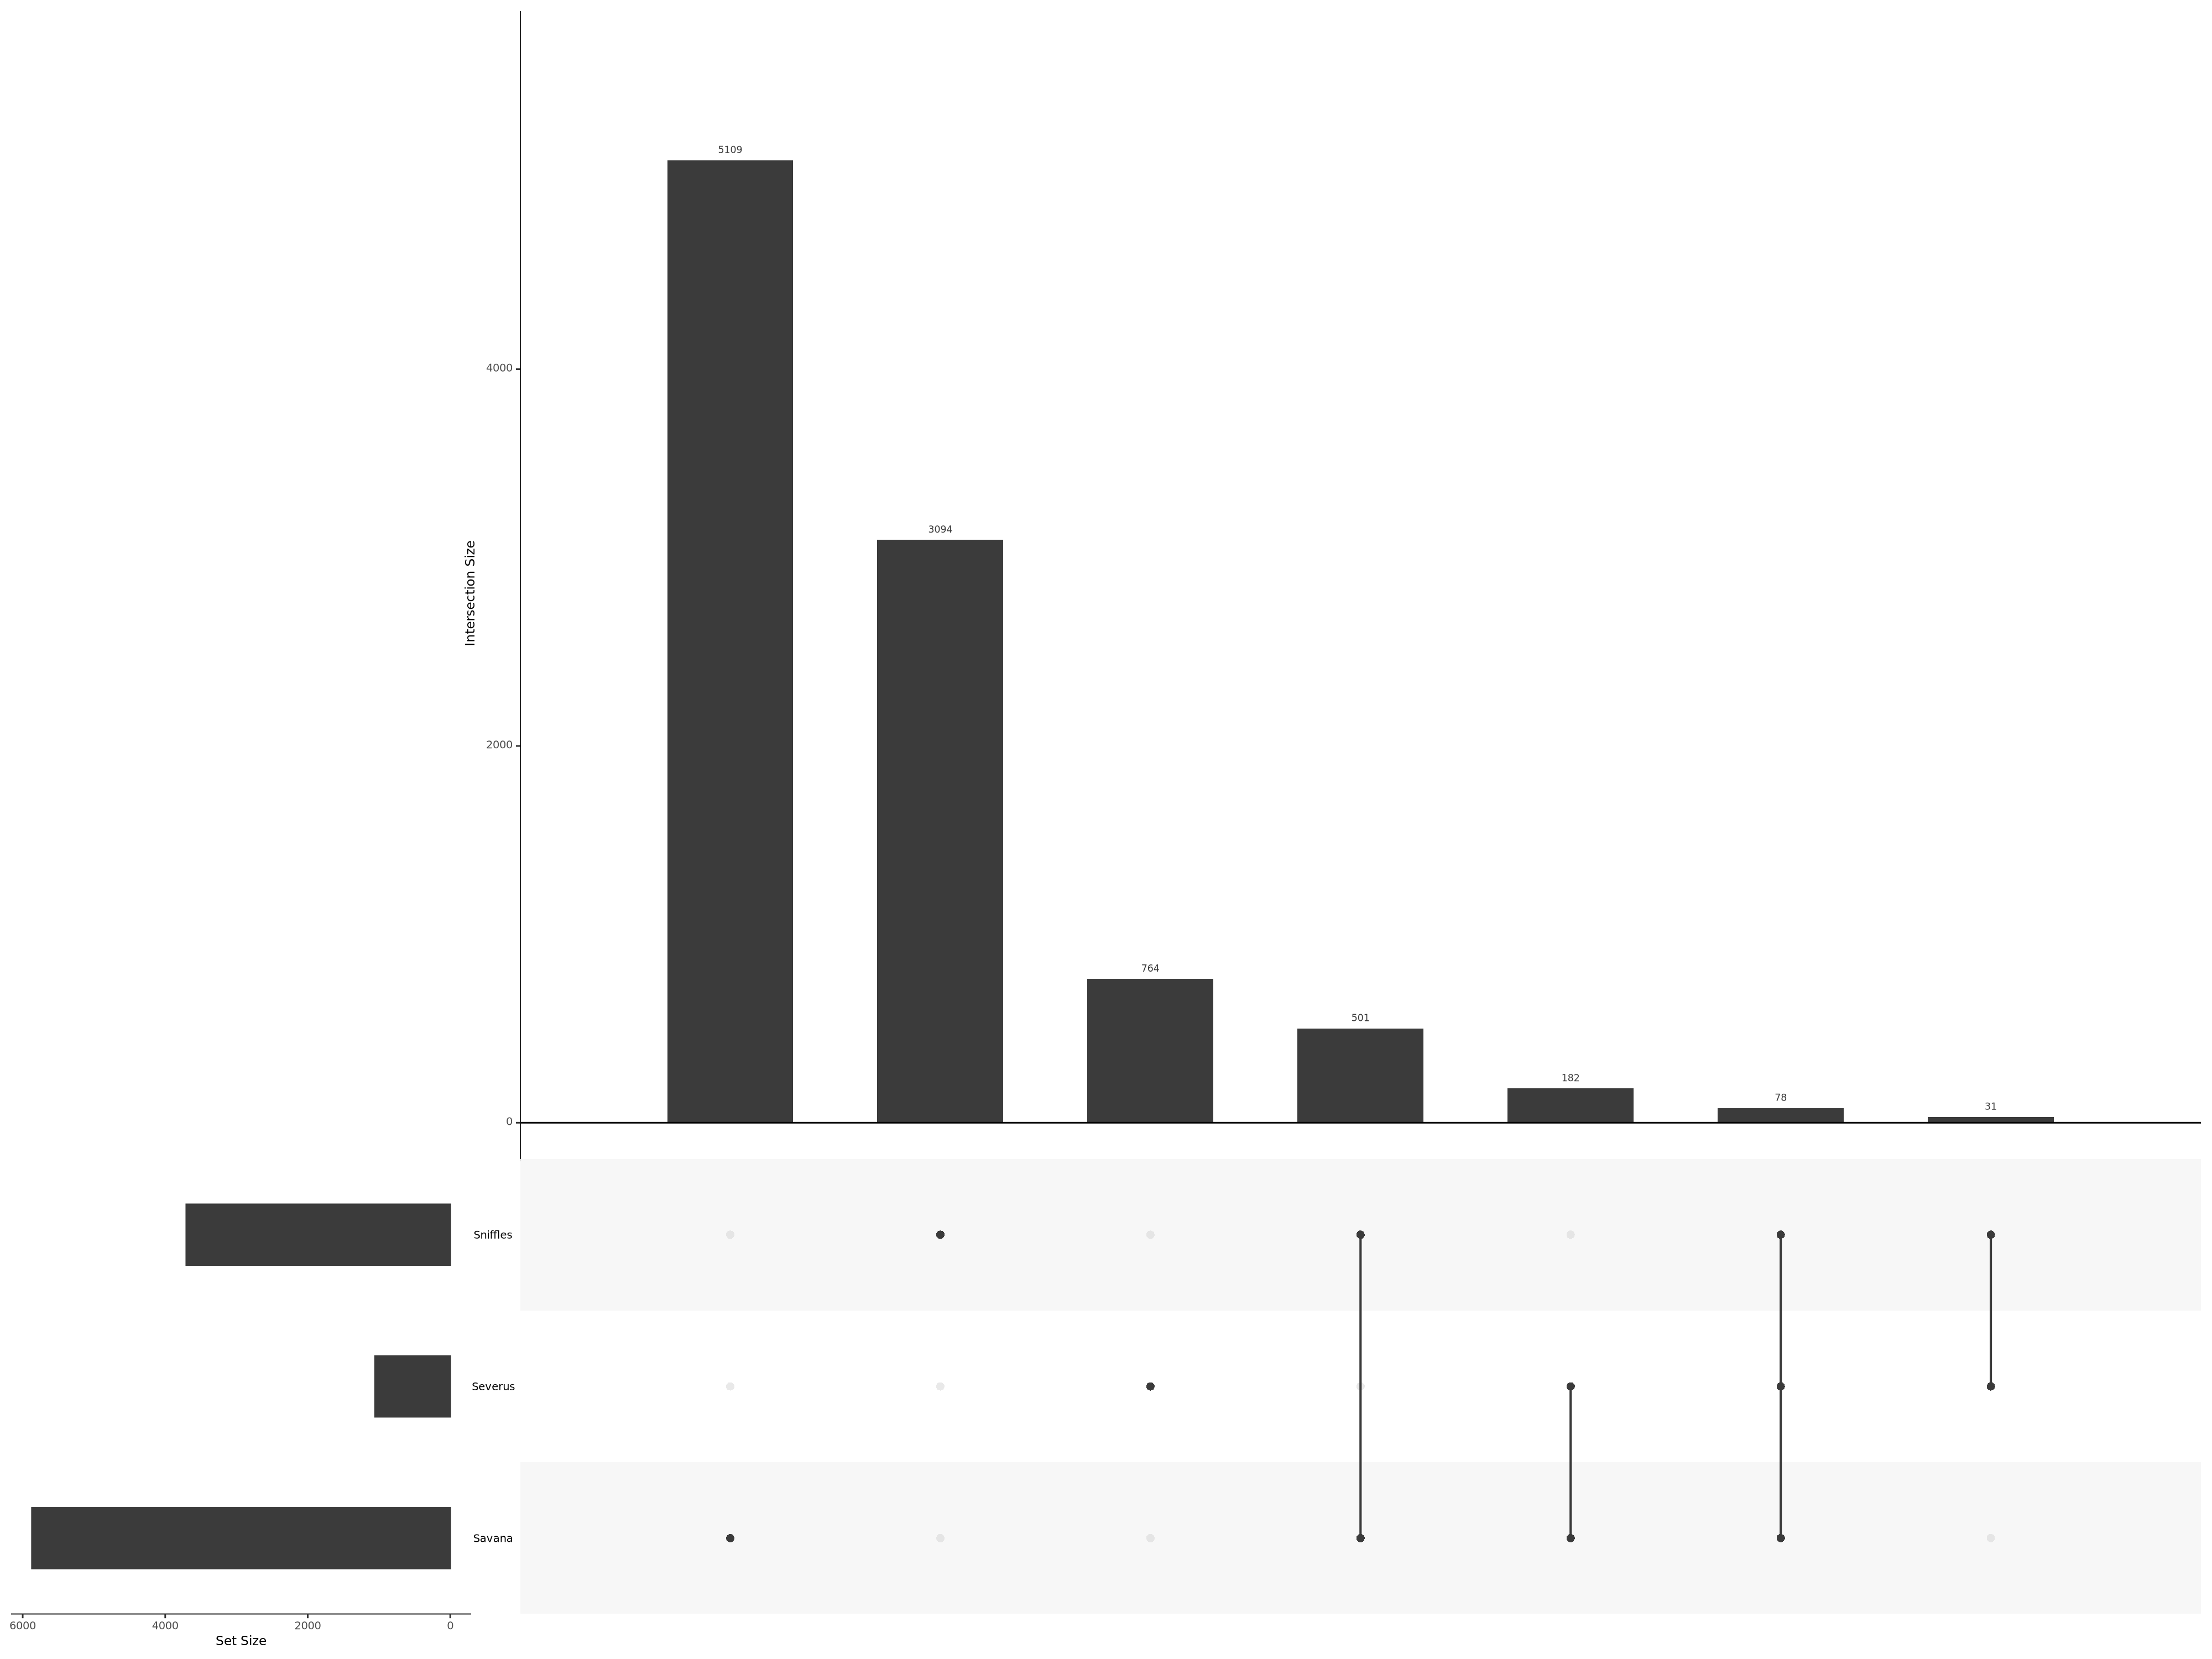

In [16]:
library(GenomicRanges)
library(UpSetR)

# 1. Convert each tool’s SVs to GRanges
gr_list <- lapply(split(all_sv, all_sv$tool), function(df) {
  GRanges(seqnames = df$chr,
          ranges = IRanges(start = df$start, end = df$end))
})

# 2. Optionally widen ranges to allow fuzzy matching (e.g., ±50 bp)
gr_list <- lapply(gr_list, function(gr) {
  resize(gr, width(gr) + 10, fix = "center")  # widen ±50bp
})

# 3. Create a combined GRanges and reduce to consensus regions
all_gr <- unlist(GRangesList(gr_list))
reduced <- reduce(all_gr)

# 4. Build presence/absence matrix
presence_mat <- sapply(gr_list, function(gr) {
  as.integer(countOverlaps(reduced, gr) > 0)
})
rownames(presence_mat) <- paste0(seqnames(reduced), ":", start(reduced), "-", end(reduced))

# 5. Convert to data frame for UpSetR
presence_df <- as.data.frame(presence_mat)

# 6. Plot UpSet
upset(presence_df, 
      sets = colnames(presence_df),
      keep.order = TRUE,
      order.by = "freq")


Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


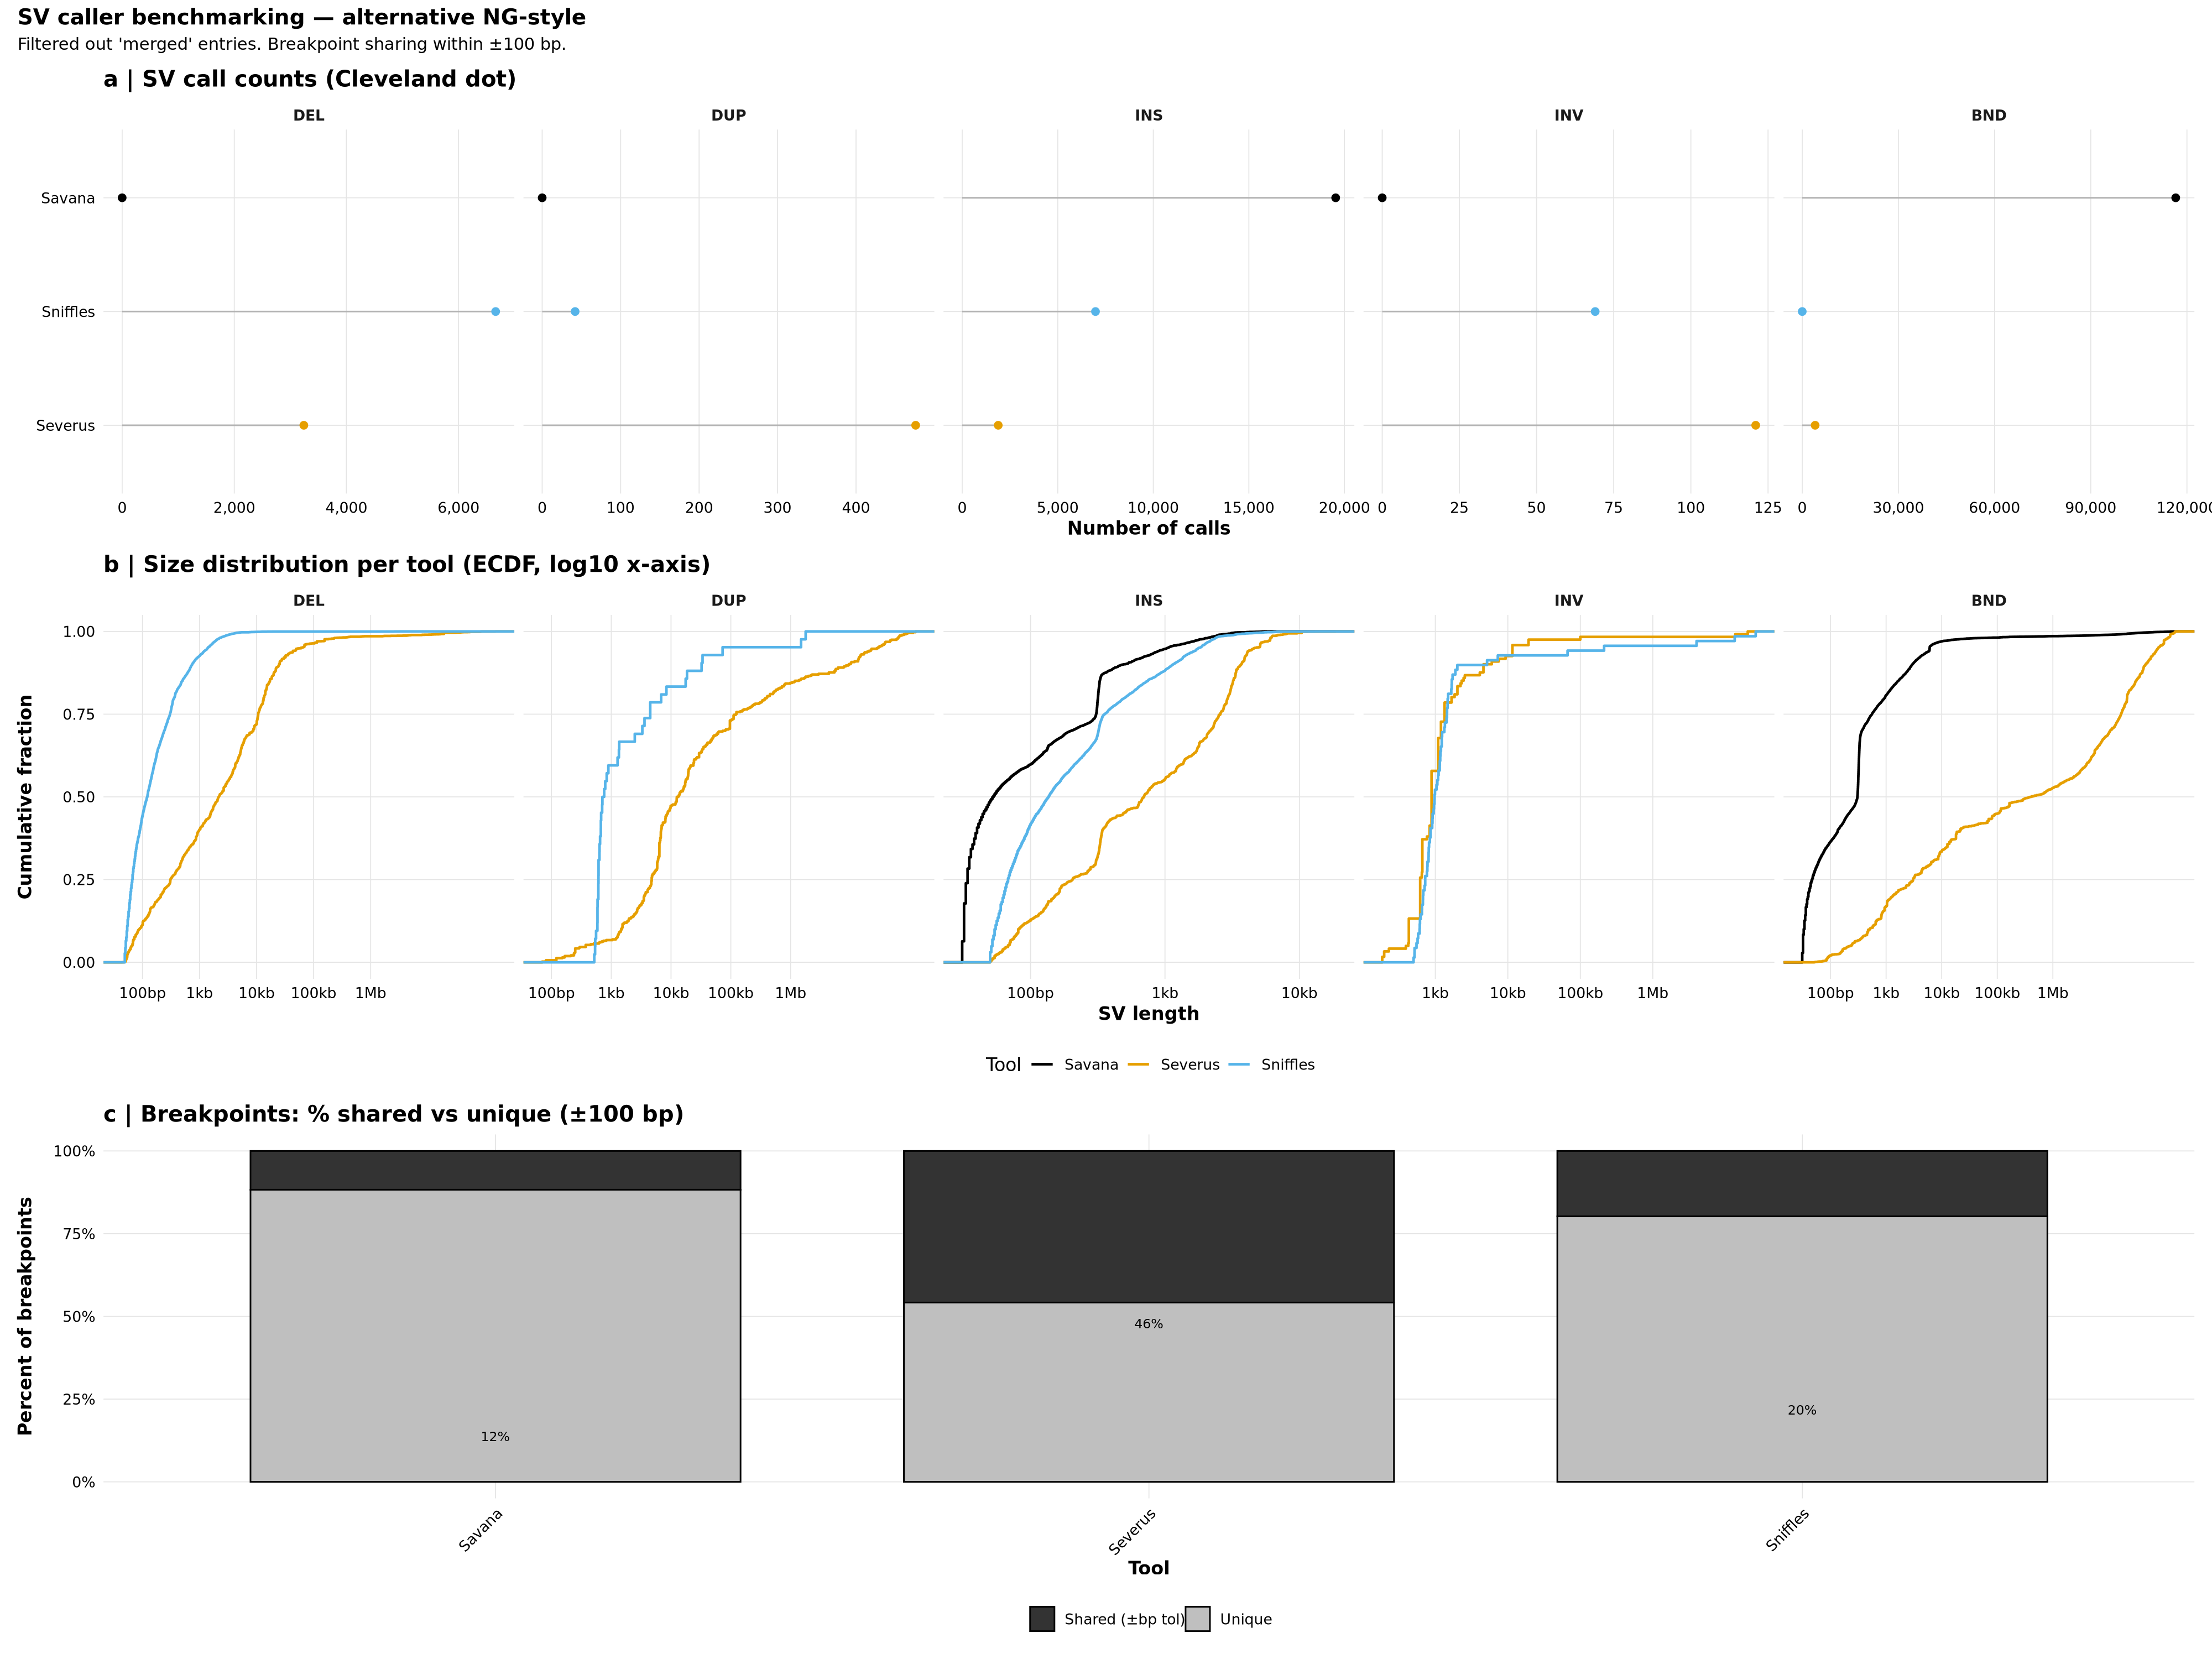

In [12]:
# ===========================================
# NG-style ALT layout (3 panels)
# a) Cleveland dot (counts)
# b) ECDF (size distributions)
# c) % Shared vs Unique breakpoints per tool (±bp_tol)
# Input: all_sv with cols: chr,start,end,size,type,sample,tool
# ===========================================

suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2)
  library(forcats); library(patchwork)
})

stopifnot(exists("all_sv"))

# ---- Options ----
drop_merged_tools   <- TRUE    # drop callers named exactly merged/union/consensus
drop_merged_samples <- TRUE    # drop samples with "merged" in name
bp_tol <- 100L                 # breakpoint tolerance for shared-vs-unique

# ---- Theme & palettes (muted, crisp) ----
theme_ng <- function(base_size = 12) {
  theme_minimal(base_size = base_size) +
    theme(
      panel.grid.major = element_line(size = 0.3, colour = "grey90"),
      panel.grid.minor = element_blank(),
      axis.title       = element_text(face = "bold"),
      axis.text        = element_text(color = "black"),
      strip.text       = element_text(face = "bold"),
      plot.title       = element_text(face = "bold", hjust = 0),
      plot.subtitle    = element_text(hjust = 0, colour = "grey30"),
      legend.position  = "bottom"
    )
}
okabe_ito <- c("#000000","#E69F00","#56B4E9","#009E73",
               "#F0E442","#0072B2","#D55E00","#CC79A7","#999999")

# ---- Clean & filter ----
df <- all_sv %>%
  transmute(
    chr    = as.character(chr),
    start  = as.integer(start),
    end    = as.integer(end),
    size   = as.numeric(size),
    type   = as.character(type),
    sample = as.character(sample),
    tool   = as.character(tool)
  ) %>%
  mutate(size = ifelse(is.na(size) | size <= 0, 1, size))

if (isTRUE(drop_merged_tools))   df <- df %>% filter(!grepl("^(merged|union|consensus)$", tool, ignore.case = TRUE))
if (isTRUE(drop_merged_samples)) df <- df %>% filter(!grepl("merged", sample, ignore.case = TRUE))
stopifnot(nrow(df) > 0)

sv_levels <- c("DEL","DUP","INS","INV","BND")
df <- df %>%
  mutate(
    type = fct_other(factor(type), keep = sv_levels) |> fct_relevel(sv_levels),
    tool = factor(tool)
  )

# Consistent tool colors across panels
tools <- levels(df$tool)
tool_cols <- setNames(rep_len(okabe_ito, length(tools)), tools)

# ===========================================
# Panel a — Cleveland dot (counts)
# ===========================================
counts_ty <- df %>%
  count(tool, type, name = "n") %>%
  complete(tool, type, fill = list(n = 0)) %>%
  group_by(tool) %>% mutate(n_total = sum(n)) %>% ungroup() %>%
  mutate(tool = fct_reorder(tool, n_total))  # global order by total

pA <- ggplot(counts_ty, aes(x = n, y = tool, color = tool)) +
  geom_segment(aes(x = 0, xend = n, y = tool, yend = tool), linewidth = 0.5, color = "grey70") +
  geom_point(size = 2) +
  facet_wrap(~ type, nrow = 1, scales = "free_x") +
  scale_color_manual(values = tool_cols, guide = "none") +
  scale_x_continuous(labels = scales::comma) +
  labs(title = "a | SV call counts (Cleveland dot)", x = "Number of calls", y = NULL) +
  theme_ng()

# ===========================================
# Panel b — ECDF curves (size, log10)
# ===========================================
pB <- ggplot(df, aes(x = size, color = tool)) +
  stat_ecdf(geom = "step", linewidth = 0.8) +
  facet_wrap(~ type, nrow = 1, scales = "free_x") +
  scale_color_manual(values = tool_cols, name = "Tool") +
  scale_x_continuous(trans = "log10",
                     breaks = c(10,1e2,1e3,1e4,1e5,1e6),
                     labels = c("10bp","100bp","1kb","10kb","100kb","1Mb")) +
  labs(title = "b | Size distribution per tool (ECDF, log10 x-axis)",
       x = "SV length", y = "Cumulative fraction") +
  theme_ng()

# ===========================================
# Panel c — % Shared vs Unique breakpoints per tool
# ===========================================
has_GR <- requireNamespace("GenomicRanges", quietly = TRUE) &&
          requireNamespace("IRanges", quietly = TRUE) &&
          requireNamespace("S4Vectors", quietly = TRUE)

pC <- NULL
if (has_GR) {
  GR <- GenomicRanges::GRanges; IR <- IRanges::IRanges

  # Build breakpoint GRanges (start & end as 1-bp points)
  bps <- bind_rows(
    df %>% transmute(tool = as.character(tool), chr, pos = as.integer(start)),
    df %>% transmute(tool = as.character(tool), chr, pos = as.integer(end))
  ) %>% filter(!is.na(pos)) %>% distinct(tool, chr, pos)

  gr_bp_by_tool <- lapply(split(bps, bps$tool), function(d) {
    GR(seqnames = d$chr, ranges = IR(start = d$pos, width = 1L))
  })
  tools_bp <- names(gr_bp_by_tool)

  # safe overlaps: findOverlaps with maxgap; fallback to distanceToNearest
  safe_hits <- function(ga, gb) {
    tryCatch(
      GenomicRanges::findOverlaps(ga, gb, maxgap = bp_tol, ignore.strand = TRUE),
      error = function(e) {
        nn <- GenomicRanges::distanceToNearest(ga, gb, ignore.strand = TRUE)
        if (length(nn) == 0) return(S4Vectors::Hits())
        keep <- which(S4Vectors::mcols(nn)$distance <= bp_tol)
        if (length(keep) == 0) S4Vectors::Hits() else
          S4Vectors::Hits(S4Vectors::queryHits(nn)[keep],
                          S4Vectors::subjectHits(nn)[keep],
                          length(ga), length(gb))
      }
    )
  }

  # For each tool, % breakpoints that match ANY other tool (shared) vs unique
  share_stats <- lapply(tools_bp, function(tnm) {
    ga <- gr_bp_by_tool[[tnm]]
    others <- setdiff(tools_bp, tnm)
    gb <- if (length(others)) Reduce(c, gr_bp_by_tool[others]) else NULL
    if (is.null(gb) || length(ga) == 0) {
      tibble(tool = tnm, n_bp = length(ga), n_shared = 0L)
    } else {
      hits <- safe_hits(ga, gb)
      n_shared <- length(unique(S4Vectors::queryHits(hits)))
      tibble(tool = tnm, n_bp = length(ga), n_shared = n_shared)
    }
  }) %>% bind_rows()

  share_stats <- share_stats %>%
    mutate(n_unique = pmax(0L, n_bp - n_shared),
           frac_shared = ifelse(n_bp > 0, n_shared / n_bp, 0),
           frac_unique = 1 - frac_shared) %>%
    pivot_longer(c(frac_shared, frac_unique),
                 names_to = "kind", values_to = "frac") %>%
    mutate(kind = recode(kind, frac_shared = "Shared (±bp tol)", frac_unique = "Unique"),
           tool = factor(tool, levels = tools))  # keep tool order consistent

  pC <- ggplot(share_stats, aes(x = tool, y = frac, fill = kind)) +
    geom_col(color = "black", width = 0.75) +
    geom_text(data = share_stats %>% group_by(tool) %>% summarise(fr = sum(frac[kind=="Shared (±bp tol)"])),
              aes(x = tool, y = fr + 0.02, label = scales::percent(fr, accuracy = 1)),
              inherit.aes = FALSE, size = 3) +
    scale_fill_manual(values = c("Shared (±bp tol)" = "grey20", "Unique" = "grey75"), name = NULL) +
    scale_y_continuous(labels = scales::percent, limits = c(0, 1)) +
    labs(title = paste0("c | Breakpoints: % shared vs unique (±", bp_tol, " bp)"),
         x = "Tool", y = "Percent of breakpoints") +
    theme_ng() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
} else {
  pC <- ggplot() + annotate("text", 0, 0, label = "Install GenomicRanges/IRanges for panel (c)") +
    theme_void() + labs(title = "c | Breakpoints: % shared vs unique (requires Bioc)")
}
options(repr.plot.width = 20, repr.plot.height = 15, repr.plot.res = 200)

# ===========================================
# Assemble & show
# ===========================================
fig <- pA / pB / pC +
  plot_annotation(
    title = "SV caller benchmarking — alternative NG-style",
    subtitle = paste0("Filtered out 'merged' entries. Breakpoint sharing within ±", bp_tol, " bp."),
    theme = theme(plot.title = element_text(face = "bold", size = 14),
                  plot.subtitle = element_text(size = 11))
  )

print(fig)

# Optional:
# ggsave("sv_benchmark_alt3panels.pdf", fig, width = 12, height = 9, units = "in")
# ggsave("sv_benchmark_alt3panels.png", fig, width = 12, height = 9, units = "in", dpi = 300)
